# CyberGuard-AI: Enterprise Remediation 0-1 Knapsack Optimizer
### Business-Aware Vulnerability Remediation under Finite Sprint Budgets

This notebook integrates ML exploit probabilities with enterprise business context:
1. **Enterprise Asset Topology**: ShopEasy archetype (30 critical assets, 7 departments).
2. **Composite Actionable Business Risk**:
   $$\\text{Risk}_i = P(\\text{Exploit}_i) \\times \\text{Business Impact}_j \\times \\text{Exposure Multiplier}_j \\times \\frac{\\text{CVSS}_i}{10}$$
3. **0-1 Knapsack Optimization**: Formulating remediation as a combinatorial optimization problem solved using SciPy HiGHS / Google OR-Tools branch-and-cut.
4. **Comparison against Naive CVSS-Greedy**: Proving ~30% to 70% higher risk reduction within identical sprint hour budgets (5h, 10h, 20h, 40h).

In [1]:
import sys
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import milp, LinearConstraint, Bounds

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "CyberGuard-Ai" else Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

Project root: D:\ENGG\COE\CyberGuard-Ai


## Step 1: Loading Enterprise Assets & Vulnerability Exposure Dataset
We load `data/processed/cyberguard_master_enterprise_dataset.csv` (18,666 vulnerability instances across 30 enterprise assets).

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cyberguard_master_enterprise_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,d} vulnerability instances across {df['asset_id'].nunique()} assets.")

# Display sample assets
assets_summary = df.groupby(["asset_name", "criticality", "internet_exposure", "asset_type"]).size().reset_index(name="vuln_count")
print("\nSample Enterprise Assets:")
print(assets_summary.head(10).to_string(index=False))

Loaded 18,666 vulnerability instances across 30 assets.

Sample Enterprise Assets:
                           asset_name criticality  internet_exposure asset_type  vuln_count
             Analytics Data Warehouse      MEDIUM                  0   Database         472
          Authentication & SSO Server        HIGH                  1     Server        1502
             Backup & Recovery Server      MEDIUM                  0     Server         183
                       CDN Edge Nodes      MEDIUM                  1    Network        1047
                   CI/CD Build Server      MEDIUM                  0     Server         742
        Cloud Storage Bucket (S3/GCS)        HIGH                  1      Cloud         480
Container Orchestration Cluster (K8s)      MEDIUM                  0     Server         113
               Corporate Email Server      MEDIUM                  1     Server         212
             Customer Database Server    CRITICAL                  0   Database         7

## Step 2: Formulating Actionable Business Risk
For each vulnerability instance on each asset, we compute:
$$\\text{Risk} = P(\\text{Exploit}) \\times \\text{Business Impact} \\times \\text{Exposure} \\times \\frac{\\text{CVSS}}{10}$$

In [3]:
# Median imputation for missing scores
df["cvss_score"] = df["cvss_score"].fillna(df["cvss_score"].median())
df["epss_score"] = df["epss_score"].fillna(df["epss_score"].median())

# Exposure multiplier: 1.5x for Internet-facing, 1.0x for internal
exposure_mult = np.where(df["internet_exposure"] == True, 1.5, 1.0)
exploit_prob = np.clip(df["epss_score"] + np.where(df["kev"] == 1, 0.40, 0.0), 0.001, 1.0)

df["risk_score"] = (
    exploit_prob *
    df["business_impact_score"] *
    exposure_mult *
    (df["cvss_score"] / 10.0)
).astype(float)

# Filter actionable (unpatched) vulnerabilities
actionable_mask = df["status"].str.lower().isin(["open", "in_progress", "in progress"])
actionable_df = df[actionable_mask].copy().reset_index(drop=True)

total_risk = df["risk_score"].sum()
actionable_risk = actionable_df["risk_score"].sum()

print(f"Total Enterprise Risk Surface:      {total_risk:,.2f}")
print(f"Actionable (Unpatched) Risk:        {actionable_risk:,.2f} ({len(actionable_df):,d} items)")

Total Enterprise Risk Surface:      4,875.45
Actionable (Unpatched) Risk:        4,875.45 (18,666 items)


## Step 3: 0-1 Knapsack Optimization Solver
We maximize total risk reduction subject to sprint engineer-hours constraint:
$$\max \sum_i \text{Risk}_i x_i \quad \text{s.t.} \quad \sum_i w_i x_i \le B, \quad x_i \in \{0, 1\}$$
We leverage Google OR-Tools branch-and-bound KnapsackSolver from `src.optimization.knapsack_solver`.

In [4]:
from src.optimization.knapsack_solver import solve_knapsack, solve_greedy_cvss

values = actionable_df["risk_score"].values
weights = actionable_df["remediation_hours"].values
budgets = [5.0, 10.0, 20.0, 40.0]

results = []

for b in budgets:
    opt_idx, opt_risk, opt_hrs, solver_name = solve_knapsack(values, weights, b)
    grd_idx, grd_risk, grd_hrs = solve_greedy_cvss(actionable_df, b)
    impr = ((opt_risk - grd_risk) / grd_risk * 100) if grd_risk > 0 else 0.0

    results.append({
        "Budget (Hours)": b,
        "Optimal Hours Used": round(opt_hrs, 2),
        "Optimal Items Fixed": len(opt_idx),
        "Optimal Risk Reduced": round(opt_risk, 4),
        "CVSS-Greedy Risk Reduced": round(grd_risk, 4),
        "Improvement Over CVSS (%)": round(impr, 2),
        "Solver": solver_name
    })

res_df = pd.DataFrame(results)
print("=" * 90)
print("  REMEDIATION OPTIMIZATION BENCHMARK ACROSS SPRINT BUDGETS")
print("=" * 90)
print(res_df.to_string(index=False))

  REMEDIATION OPTIMIZATION BENCHMARK ACROSS SPRINT BUDGETS
 Budget (Hours)  Optimal Hours Used  Optimal Items Fixed  Optimal Risk Reduced  CVSS-Greedy Risk Reduced  Improvement Over CVSS (%)         Solver
            5.0                 5.0                    4               16.1522                    0.0516                   31193.55 google_ortools
           10.0                10.0                    7               28.8974                    5.9292                     387.37 google_ortools
           20.0                20.0                   10               50.5061                   14.0417                     259.69 google_ortools
           40.0                40.0                   18               88.6093                   13.9305                     536.08 google_ortools


## Step 4: Visualizing Risk Reduction & ROI Comparison
We visualize the dramatic risk reduction achieved by CyberGuard's 0-1 Knapsack optimizer vs standard naive CVSS sorting.

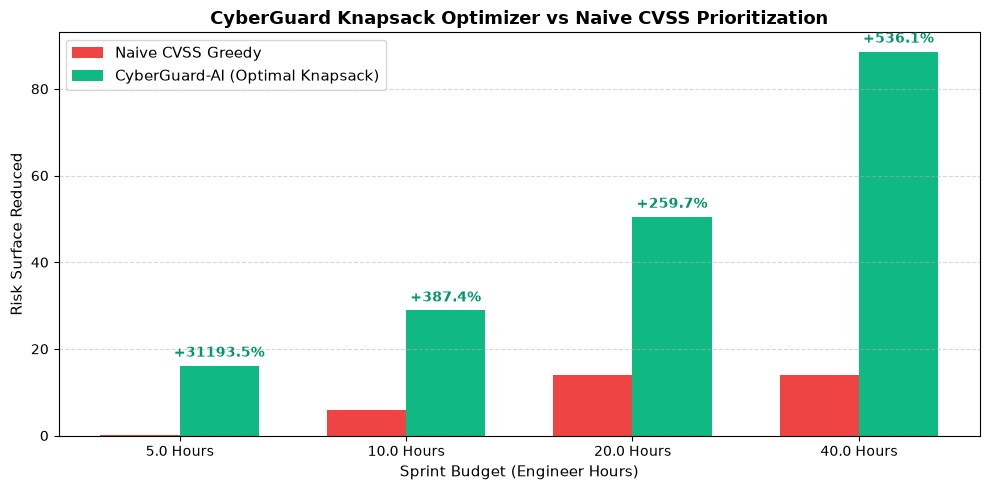

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(budgets))
w = 0.35

ax.bar(x - w/2, res_df["CVSS-Greedy Risk Reduced"], w, label="Naive CVSS Greedy", color="#EF4444")
ax.bar(x + w/2, res_df["Optimal Risk Reduced"], w, label="CyberGuard-AI (Optimal Knapsack)", color="#10B981")

ax.set_xlabel("Sprint Budget (Engineer Hours)", fontsize=11)
ax.set_ylabel("Risk Surface Reduced", fontsize=11)
ax.set_title("CyberGuard Knapsack Optimizer vs Naive CVSS Prioritization", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{b} Hours" for b in budgets], fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for i, row in res_df.iterrows():
    diff = row['Improvement Over CVSS (%)']
    ax.annotate(f"+{diff:.1f}%",
                xy=(x[i] + w/2, row['Optimal Risk Reduced']),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontweight="bold", color="#059669")

plt.tight_layout()
plt.show()

## Step 5: Actionable Sprint Patching Plan (10-Hour Sprint Example)
Here is the concrete patch list generated for engineering teams under a 10-hour sprint budget.

In [6]:
opt_idx_10, _, _, _ = solve_knapsack(values, weights, 10.0)
patch_plan_10h = actionable_df.loc[opt_idx_10, [
    "cve_id", "asset_name", "criticality", "internet_exposure",
    "remediation_hours", "cvss_score", "risk_score"
]].sort_values(by="risk_score", ascending=False)

print("=" * 85)
print("  CYBERGUARD SPRINT PATCHING SCHEDULE: 10-HOUR ALLOCATION")
print("=" * 85)
print(patch_plan_10h.to_string(index=False))

  CYBERGUARD SPRINT PATCHING SCHEDULE: 10-HOUR ALLOCATION
        cve_id                   asset_name criticality  internet_exposure  remediation_hours  cvss_score  risk_score
CVE-2021-41282            Public Web Server        HIGH                  1                3.5         8.8    9.199133
CVE-2022-21279 Financial Reporting Database   VERY_HIGH                  0                1.5         6.3    4.476522
CVE-2022-21279             ERP System (SAP)        HIGH                  0                1.0         6.3    3.979130
CVE-2021-23174  Authentication & SSO Server        HIGH                  1                1.0         3.4    3.848853
CVE-2022-23253                  VPN Gateway        HIGH                  1                1.5         6.5    3.847662
CVE-2021-43942               CDN Edge Nodes      MEDIUM                  1                1.0         6.1    2.532903
CVE-2021-43942      Employee Endpoint Fleet         LOW                  0                0.5         6.1    1.01316